# Derived Kickbase points by minutes played

Each observation is one player appearance from the latest points export, across all its recorded matches and competitions. Source player eligibility still applies. These are SofaScore-derived estimates, including proxy awards, not official Kickbase points.

Groups are **10 ≤ minutes < 25**, **25 ≤ minutes < 50**, **50 ≤ minutes < 75**, and **75+ minutes** (no upper limit). Missing ratings never remove an otherwise valid appearance.


In [11]:
import json
import sys
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display

def locate_project_root():
    for start in (Path.cwd().resolve(), Path(globals().get('__vsc_ipynb_file__', '.')).resolve()):
        for candidate in (start, *start.parents):
            if (candidate / 'project_paths.py').is_file():
                return candidate
    raise FileNotFoundError('Run this notebook from within the project directory.')

PROJECT_ROOT = locate_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from project_paths import SOFASCORE_PLAYER_KICKBASE_POINT_AVERAGES_DIR, SOFASCORE_PLAYER_AVERAGE_RATINGS_DIR, SOFASCORE_TEAM_FORM_DIR

GROUPS = ['10–25 min', '25–50 min', '50–75 min', '75+ min']
KEYS = ['team_id', 'player_id', 'match_id']
COLORS = dict(zip(GROUPS, px.colors.qualitative.Safe[:4]))

def latest_recording(directory, pattern):
    candidates = []
    for path in directory.glob(pattern):
        payload = json.loads(path.read_text(encoding='utf-8'))
        timestamp = datetime.fromisoformat(payload['generated_at'].replace('Z', '+00:00'))
        if timestamp.tzinfo is None:
            timestamp = timestamp.replace(tzinfo=timezone.utc)
        candidates.append((timestamp, path.name, path, payload))
    if not candidates:
        raise FileNotFoundError(f'No {pattern} in {directory}. Run the source notebook first.')
    return max(candidates, key=lambda item: item[:2])[2:]

def flatten(payload, ratings=False):
    rows = []
    for team_id, team in payload['teams'].items():
        for player in team.get('overall', {}).get('players', []):
            for match in player.get('ratings' if ratings else 'match_calculations', []):
                row = dict(team_id=str(team_id), player_id=int(player['player_id']), match_id=int(match['match_id']))
                if ratings:
                    row['rating'] = match.get('rating')
                else:
                    row.update(player_name=player.get('player_name'), team=team.get('team'),
                               minutes=match.get('minutes_played'), points=match.get('calculated_kickbase_points'))
                rows.append(row)
    columns = KEYS + (['rating'] if ratings else ['player_name', 'team', 'minutes', 'points'])
    frame = pd.DataFrame(rows, columns=columns)
    if frame.duplicated(KEYS).any():
        raise ValueError('Duplicate team/player/match records in source export.')
    return frame

def group_appearances(frame):
    frame = frame.copy()
    for column in ['minutes', 'points']:
        frame[column] = pd.to_numeric(frame[column], errors='coerce')
    valid = np.isfinite(frame[['minutes', 'points']]).all(axis=1)
    included = frame.loc[valid & frame.minutes.ge(10)].copy()
    included['group'] = pd.cut(included.minutes, [10, 25, 50, 75, np.inf], labels=GROUPS, right=False)
    counts = {'source': len(frame), 'invalid points/minutes': int((~valid).sum()),
              'below 10 minutes': int((valid & frame.minutes.lt(10)).sum()), 'included': len(included)}
    assert sum(counts[k] for k in ['invalid points/minutes', 'below 10 minutes', 'included']) == counts['source']
    return included, counts

def percentile_table(frame):
    quantiles = np.arange(11) / 10
    return pd.DataFrame({group: frame.loc[frame['group'] == group, 'points'].quantile(quantiles, interpolation='linear').to_numpy()
                         for group in GROUPS}, index=[f'P{i}' for i in range(0, 101, 10)])

def match_metadata(payload):
    source = payload.get('source_file')
    path = SOFASCORE_TEAM_FORM_DIR / Path(source).name if source else None
    if path is None or not path.is_file():
        print(f'Team-form recording unavailable: {source}')
        return pd.DataFrame(columns=['team_id', 'match_id', 'fixture', 'date'])
    document = json.loads(path.read_text(encoding='utf-8'))
    teams = document[max(document, key=lambda value: pd.Timestamp(value))]
    rows = []
    for team_id, team in teams.items():
        for match in team.get('overall_matches', []):
            home, away = match.get('home_team'), match.get('away_team')
            rows.append(dict(team_id=str(team_id), match_id=int(match['match_id']),
                             fixture=f'{home} vs {away}' if home and away else None, date=match.get('date')))
    frame = pd.DataFrame(rows, columns=['team_id', 'match_id', 'fixture', 'date'])
    if frame.duplicated(['team_id', 'match_id']).any():
        raise ValueError(f'Duplicate team/match metadata in {path.name}')
    return frame

def attach_details(appearances, rating_rows, primary, fallback):
    metadata_keys = ['team_id', 'match_id']
    metadata = primary.set_index(metadata_keys).combine_first(fallback.set_index(metadata_keys)).reset_index()
    merged = appearances.merge(rating_rows, on=KEYS, how='left', validate='one_to_one')
    merged = merged.merge(metadata, on=metadata_keys, how='left', validate='many_to_one')
    assert len(merged) == len(appearances)
    return merged


In [12]:
points_path, points_payload = latest_recording(SOFASCORE_PLAYER_KICKBASE_POINT_AVERAGES_DIR, 'overall_player_kickbase_point_averages_*.json')
ratings_path, ratings_payload = latest_recording(SOFASCORE_PLAYER_AVERAGE_RATINGS_DIR, 'team_player_average_ratings_*.json')
for label, path, payload in [('Points', points_path, points_payload), ('Ratings', ratings_path, ratings_payload)]:
    print(f'{label}: {path.name} | Generated: {payload["generated_at"]} | Team form: {payload.get("source_file")}')
if points_payload.get('source_file') != ratings_payload.get('source_file'):
    print('Source histories differ. Ratings are joined only on identical team/player/match IDs.')

appearances, exclusion_counts = group_appearances(flatten(points_payload))
data = attach_details(appearances, flatten(ratings_payload, ratings=True), match_metadata(points_payload), match_metadata(ratings_payload))
data['rating'] = pd.to_numeric(data.rating, errors='coerce').replace([np.inf, -np.inf], np.nan)
data['rating_hover'] = data.rating.map(lambda value: f'{value:.1f}' if pd.notna(value) else 'Unavailable')
data['date_hover'] = data.date.map(lambda value: str(value) if pd.notna(value) else 'Unavailable')
for column in ['player_name', 'team', 'fixture']:
    data[column] = data[column].fillna('Unavailable')
display(pd.Series(exclusion_counts, name='Appearances').to_frame())
print(f'Missing ratings: {data.rating.isna().sum()} appearances; missing fixture/date: {((data.fixture == "Unavailable") | data.date.isna()).sum()} appearances')
print(f'Failed matches recorded in points source: {len(points_payload.get("failed_matches", []))}')
sample_counts = data.groupby('group', observed=False).size().reindex(GROUPS, fill_value=0)
display(sample_counts.rename('Appearances').to_frame())


Points: overall_player_kickbase_point_averages_2026-09-15_13-43-45_436905+0200.json | Generated: 2026-09-15T13:43:45+02:00 | Team form: team_form_2026-09-15_13-39-34_737941+0200.json
Ratings: team_player_average_ratings_2026-09-15_13-42-52_411631+0200.json | Generated: 2026-09-15T13:42:52+02:00 | Team form: team_form_2026-09-15_13-39-34_737941+0200.json


,Appearances
source,1150
invalid points/minutes,0
below 10 minutes,45
included,1105


Missing ratings: 10 appearances; missing fixture/date: 0 appearances
Failed matches recorded in points source: 9


,Appearances
group,
10–25 min,138
25–50 min,157
50–75 min,188
75+ min,622


## Points by minutes group
Each dot is one appearance. Horizontal jitter only separates overlapping dots; it does not encode minutes within the group. Hover to inspect the player, match, and SofaScore rating.


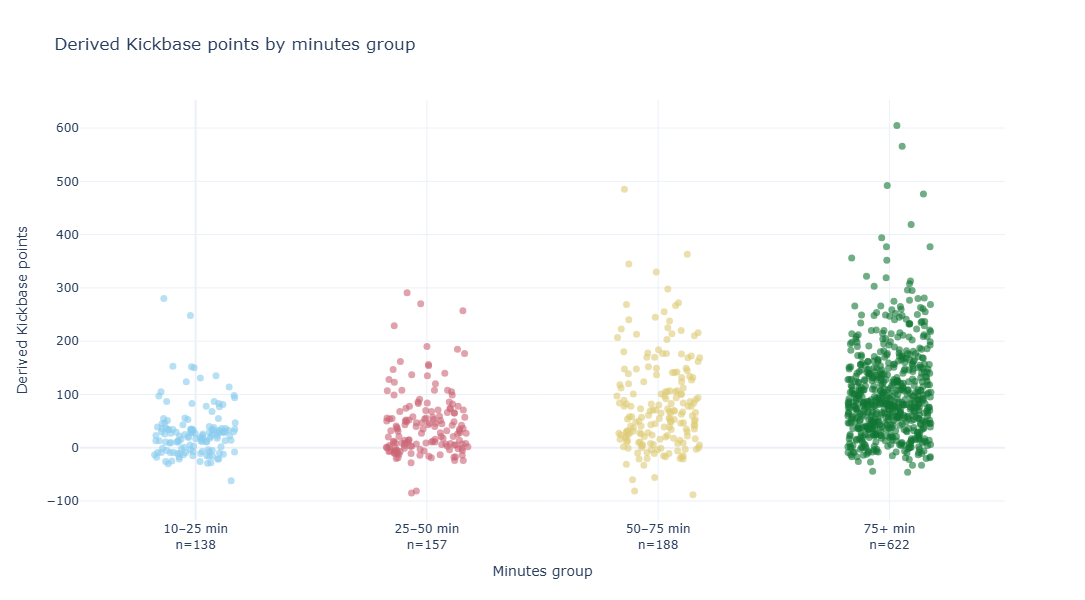

In [13]:
HOVER = ['player_name', 'team', 'fixture', 'date_hover', 'match_id', 'rating_hover', 'minutes', 'points']
HOVER_TEMPLATE = ('<b>%{customdata[0]}</b><br>Team: %{customdata[1]}<br>Match: %{customdata[2]}'
                  '<br>Date: %{customdata[3]}<br>Match ID: %{customdata[4]}'
                  '<br>SofaScore rating: %{customdata[5]}<br>Minutes: %{customdata[6]}'
                  '<br>Derived points: %{customdata[7]}<extra></extra>')
rng = np.random.default_rng(42)
fig_groups = go.Figure()
for index, group in enumerate(GROUPS):
    subset = data.loc[data['group'] == group]
    fig_groups.add_trace(go.Scatter(x=index + rng.uniform(-0.18, 0.18, len(subset)), y=subset.points,
        mode='markers', name=group, marker=dict(color=COLORS[group], opacity=0.6, size=7),
        customdata=subset[HOVER].to_numpy(), hovertemplate=HOVER_TEMPLATE))
fig_groups.update_layout(title='Derived Kickbase points by minutes group', template='plotly_white', height=600,
    xaxis=dict(title='Minutes group', tickmode='array', tickvals=list(range(4)),
               ticktext=[f'{group}<br>n={sample_counts[group]}' for group in GROUPS], range=[-0.5, 3.5]),
    yaxis_title='Derived Kickbase points', showlegend=False)
fig_groups.show()


## Actual minutes versus points
Actual minutes are preserved, including appearances above 90 minutes.

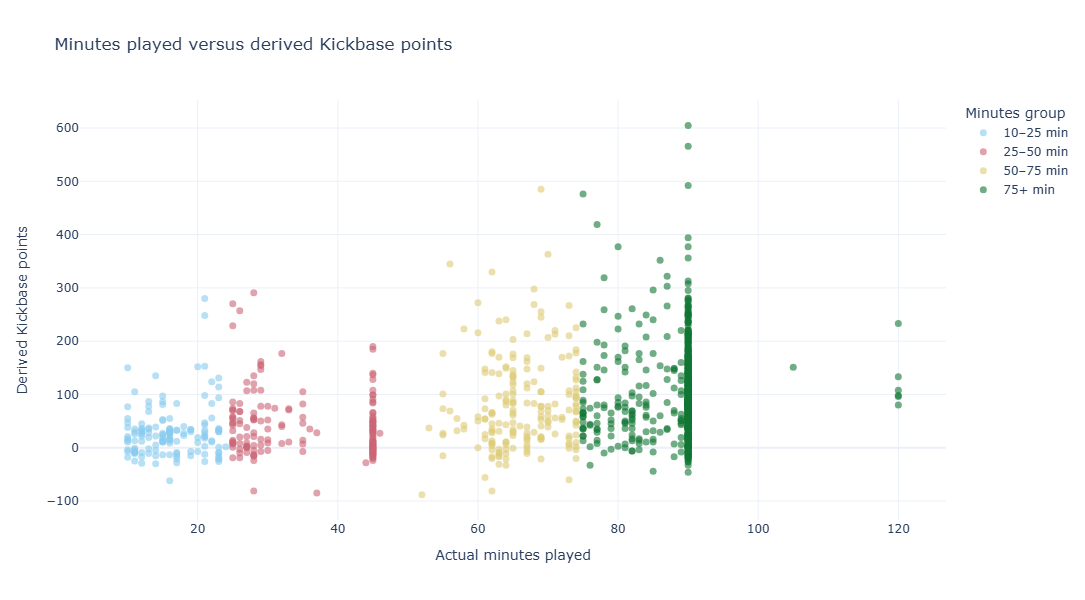

In [14]:
fig_minutes = go.Figure()
for group in GROUPS:
    subset = data.loc[data['group'] == group]
    fig_minutes.add_trace(go.Scatter(x=subset.minutes, y=subset.points, mode='markers', name=group,
        marker=dict(color=COLORS[group], opacity=0.6, size=7),
        customdata=subset[HOVER].to_numpy(), hovertemplate=HOVER_TEMPLATE))
fig_minutes.update_layout(title='Minutes played versus derived Kickbase points', template='plotly_white', height=600,
                          xaxis_title='Actual minutes played', yaxis_title='Derived Kickbase points', legend_title='Minutes group')
fig_minutes.show()


## Point distributions by group
All four histograms use the same 25-point bins and axis ranges. Hover shows the interval and appearance count. Intervals include the lower bound and exclude the upper bound.


In [15]:
BIN_WIDTH = 25
lower = np.floor(data.points.min() / BIN_WIDTH) * BIN_WIDTH if len(data) else 0
upper = (np.floor(data.points.max() / BIN_WIDTH) + 1) * BIN_WIDTH if len(data) else BIN_WIDTH
bin_edges = np.arange(lower, upper + BIN_WIDTH, BIN_WIDTH)
hist_counts = {group: np.histogram(data.loc[data['group'] == group, 'points'], bins=bin_edges)[0] for group in GROUPS}
max_count = max(1, max(int(counts.max()) for counts in hist_counts.values()))

def distribution_figure(group):
    figure = go.Figure(go.Bar(x=(bin_edges[:-1] + bin_edges[1:]) / 2,
        y=hist_counts[group], width=BIN_WIDTH, marker_color=COLORS[group],
        customdata=np.column_stack([bin_edges[:-1], bin_edges[1:]]),
        hovertemplate='Points: [%{customdata[0]}, %{customdata[1]})<br>Appearances: %{y}<extra></extra>'))
    figure.update_layout(title=f'{group}: points distribution (n={sample_counts[group]})', template='plotly_white',
        xaxis=dict(title='Derived Kickbase points', range=[lower, upper]),
        yaxis=dict(title='Appearances', range=[0, max_count * 1.1]), height=380, bargap=0)
    if sample_counts[group] == 0:
        figure.add_annotation(text='No appearances in this group', xref='paper', yref='paper', x=0.5, y=0.5, showarrow=False)
    return figure


### 10–25 min

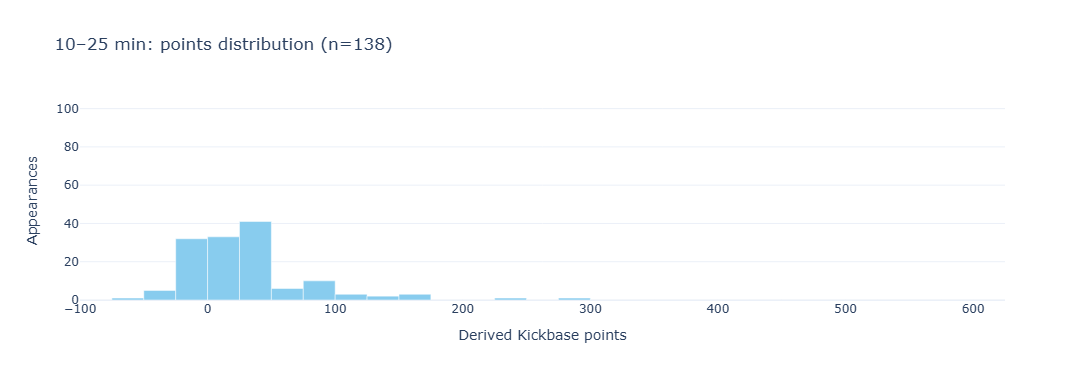

In [16]:
distribution_figure('10–25 min').show()


### 25–50 min

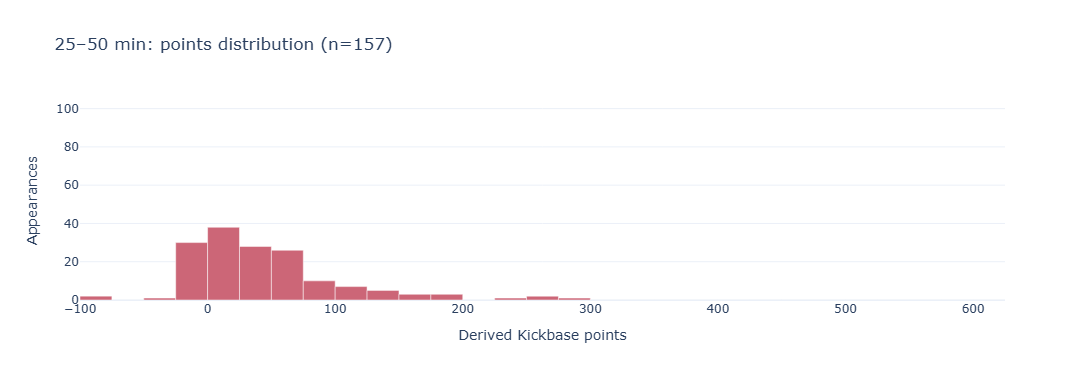

In [17]:
distribution_figure('25–50 min').show()


### 50–75 min

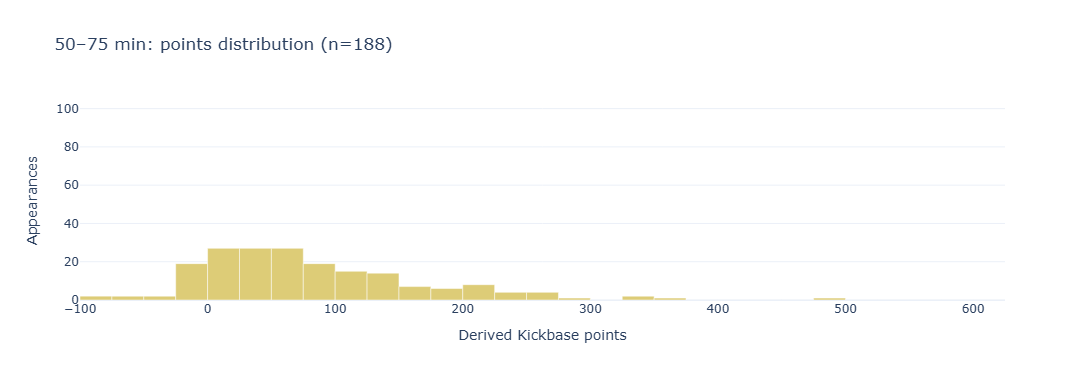

In [18]:
distribution_figure('50–75 min').show()


### 75+ min

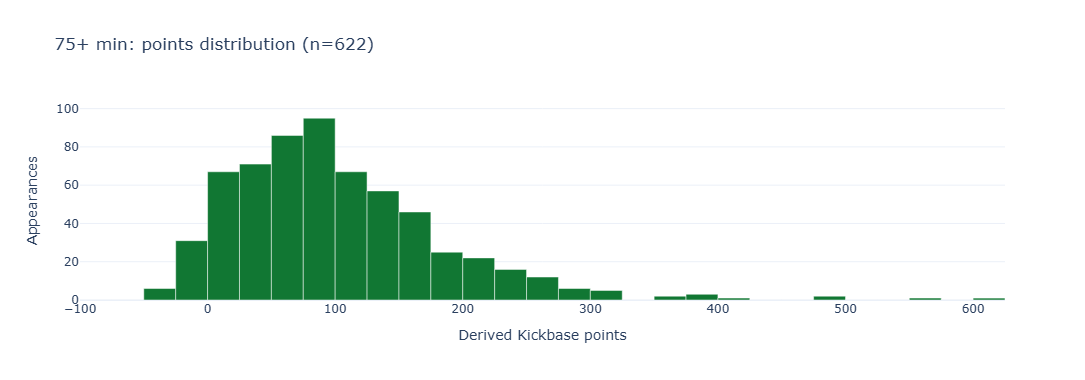

In [19]:
distribution_figure('75+ min').show()


## Percentile thresholds
P90 is the point threshold at the 90th percentile within that minutes group. P0 and P100 are the minimum and maximum. Thresholds use linear interpolation, so they can fall between observed totals. Values are displayed to one decimal place; empty groups remain blank. Each appearance has equal weight.


In [20]:
percentiles = percentile_table(data)
percentiles.index.name = 'Percentile'
display(sample_counts.rename('Appearances').to_frame().T)
display(percentiles.style.format('{:.1f}', na_rep=''))


group,10–25 min,25–50 min,50–75 min,75+ min
Appearances,138,157,188,622


,10–25 min,25–50 min,50–75 min,75+ min
Percentile,,,,
P0,-62.0,-85.0,-88.0,-46.0
P10,-15.3,-11.0,-4.6,9.1
P20,-8.6,-1.0,11.8,35.0
P30,5.4,7.0,28.0,52.3
P40,13.8,14.0,45.8,71.4
P50,22.5,32.0,64.0,85.0
P60,29.2,46.0,82.2,104.0
P70,34.0,56.2,105.0,128.0
P80,46.2,77.2,146.8,157.0


## Percentile comparison
Each line shows the table’s point thresholds for one minutes group. Hover to compare groups at the same percentile. P0 and P100 show the minimum and maximum; connecting lines guide the eye between the calculated deciles.


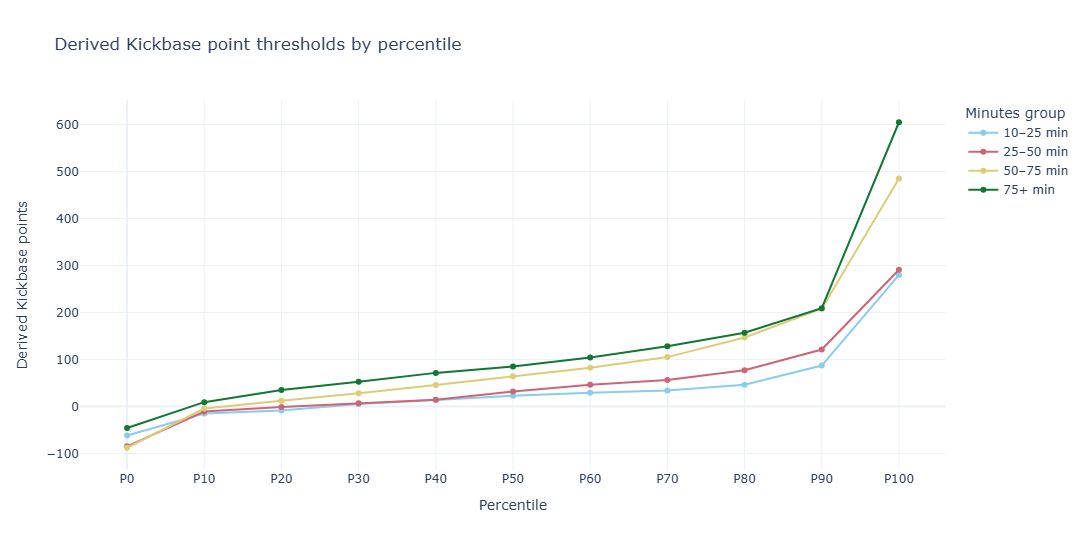

In [21]:
fig_percentiles = go.Figure()
for group in GROUPS:
    fig_percentiles.add_trace(go.Scatter(
        x=list(range(0, 101, 10)), y=percentiles[group],
        mode='lines+markers', name=group, line=dict(color=COLORS[group]),
        connectgaps=False,
        hovertemplate='Percentile: P%{x}<br>Derived points: %{y:.1f}<extra>%{fullData.name}</extra>'))
fig_percentiles.update_layout(
    title='Derived Kickbase point thresholds by percentile', template='plotly_white', height=550,
    xaxis=dict(title='Percentile', tickmode='array', tickvals=list(range(0, 101, 10)),
               ticktext=[f'P{i}' for i in range(0, 101, 10)]),
    yaxis_title='Derived Kickbase points', legend_title='Minutes group', hovermode='x unified')
fig_percentiles.show()
